#      Test MLP predictor for crypto

I wrote two functions to make testing easier:

 - `run_single_case` is for running a single backtest. It prints a few result statistics and generates a detailed tearsheet.

 - `parameter_grid_search` is for running a grid search for different parameter values. It takes the parameters that should be varied and ther list of values as arguments, as well as any other parameter-values (ie not varied) that should be passed to the single-case run. It produces a table with the arguments used and the returns produced, and a heatmap to visualise the results in a grid.

In [1]:
from run_single_case import run_single_case
from run_grid_case import parameter_grid_search

## Test single cases of `BTC-USD`

🧠 Predicting 2025-12-31 |  365/365 |  last: 1.25s |  elapsed: 14m 31.2s
✅ Prediction complete. Took 14m 34.7s


📊 --- QUICK PORTFOLIO RESULTS: BTC-USD ML Walk Forward ---
   Frictionless Return: -27.37%
   Net Strategy Return: -31.19% (EW Benchmark: -5.35%)
   Max Drawdown:        -59.77%
   Win Rate (Gross Bars):     48.5% (EW Benchmark (Bars): 50.1%)
   Loss Rate (Gross Bars):    51.0% (EW Benchmark (Bars): 49.6%)
   Total Fees Paid:     $38,141.01
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/BTC-USD_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


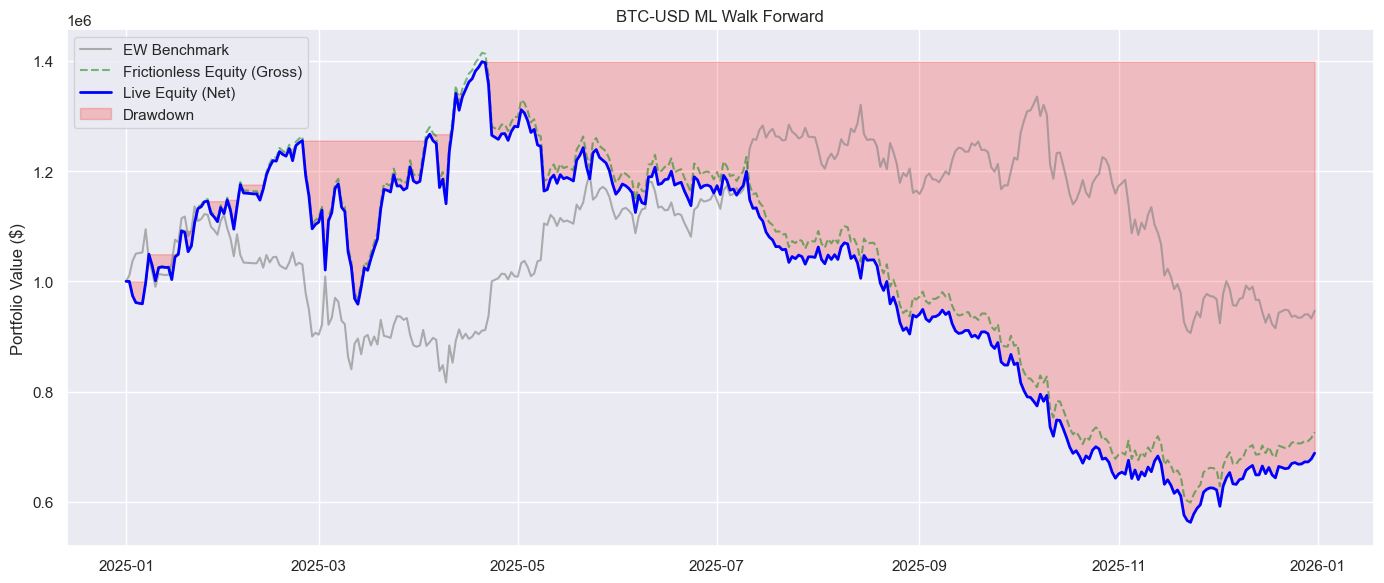

In [2]:
run_single_case("BTC-USD", start_date="2025-01-01", end_date="2026-01-01", n_features=10, signal_threshold=0.002, training_years=5)

🧠 Predicting 2025-12-31 |  365/365 |  last: 4.33s |  elapsed: 17m 32.7s
✅ Prediction complete. Took 17m 34.5s


📊 --- QUICK PORTFOLIO RESULTS: BTC-USD ML Walk Forward ---
   Frictionless Return: -7.85%
   Net Strategy Return: -10.98% (EW Benchmark: -5.35%)
   Max Drawdown:        -41.05%
   Win Rate (Gross Bars):     46.0% (EW Benchmark (Bars): 50.1%)
   Loss Rate (Gross Bars):    48.2% (EW Benchmark (Bars): 49.6%)
   Total Fees Paid:     $31,295.12
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/BTC-USD_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


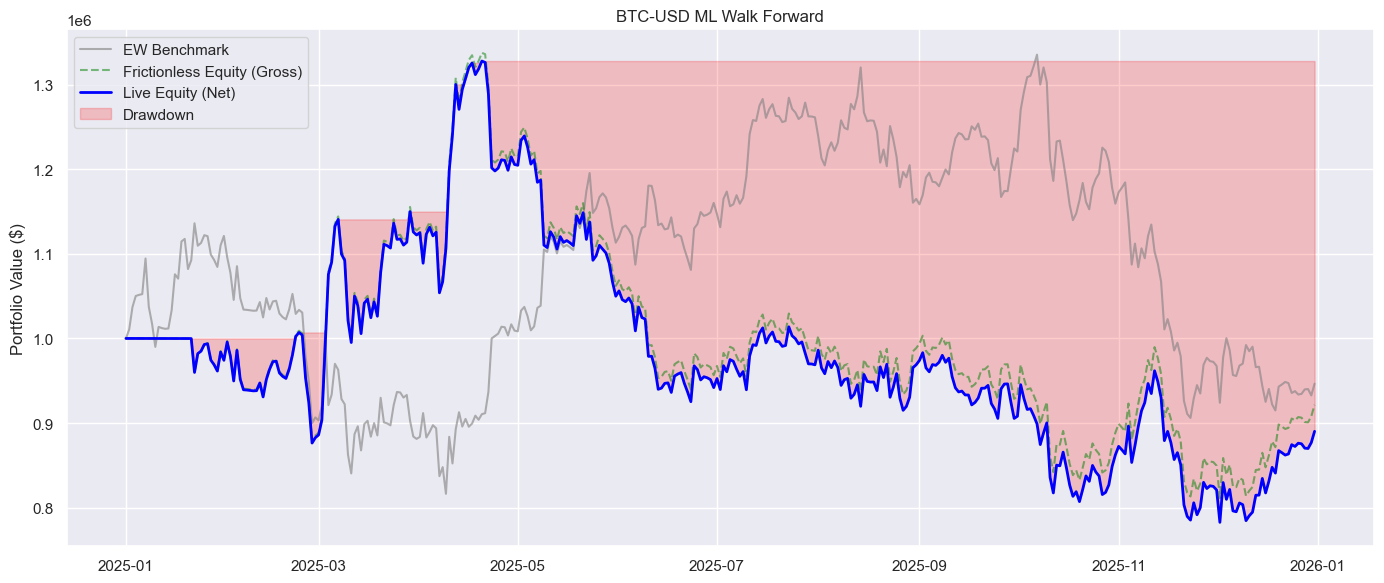

In [3]:
run_single_case("BTC-USD", start_date="2025-01-01", end_date="2026-01-01", n_features=10, signal_threshold=0.002, training_years=10)

## Grid search BTC-USD for `training_years` and `n_features`

From the following results, seems like small `training_years` and small `n_features` may work best, or at least well enough while being faster.

I decided to use `training_years = 2` and `n_features = 2` as standard

            Year 2018:

,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,verbose,show_progress,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,BTC-USD,2018-01-01,2018-12-31,0.005,1,1,1.0,5000,False,False,-62.108762,-61.741665,3.789124e+05,3.825834e+05
1,BTC-USD,2018-01-01,2018-12-31,0.005,2,1,1.0,5000,False,False,-84.206407,-83.765266,1.579359e+05,1.623473e+05
2,BTC-USD,2018-01-01,2018-12-31,0.005,3,1,1.0,5000,False,False,-82.825797,-82.249023,1.717420e+05,1.775098e+05
3,BTC-USD,2018-01-01,2018-12-31,0.005,5,1,1.0,5000,False,False,-86.713827,-85.995877,1.328617e+05,1.400412e+05
4,BTC-USD,2018-01-01,2018-12-31,0.005,10,1,1.0,5000,False,False,-85.422030,-84.417873,1.457797e+05,1.558213e+05
5,BTC-USD,2018-01-01,2018-12-31,0.005,15,1,1.0,5000,False,False,-93.806133,-92.864004,6.193867e+04,7.135996e+04
6,BTC-USD,2018-01-01,2018-12-31,0.005,20,1,1.0,5000,False,False,-89.184616,-88.304426,1.081538e+05,1.169557e+05
7,BTC-USD,2018-01-01,2018-12-31,0.005,30,1,1.0,5000,False,False,-85.289719,-83.758776,1.471028e+05,1.624122e+05
8,BTC-USD,2018-01-01,2018-12-31,0.005,1,2,1.0,5000,False,False,-51.670638,-51.207982,4.832936e+05,4.879202e+05
9,BTC-USD,2018-01-01,2018-12-31,0.005,2,2,1.0,5000,False,False,-40.967573,-39.893048,5.903243e+05,6.010695e+05


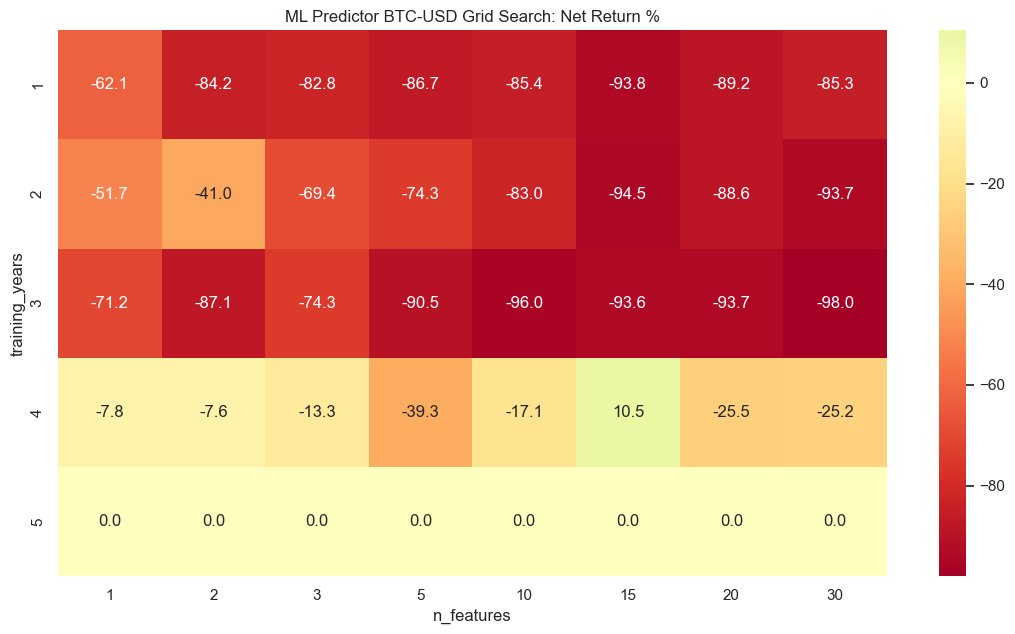

In [3]:
parameter_grid_search(
    symbol="BTC-USD",
    var_1="training_years", list_1=[1, 2, 3, 4, 5], 
    # var_1="training_years", list_1=[1, 2],
    var_2="n_features", list_2=[1, 2, 3, 5, 10, 15, 20, 30],
    # var_2="n_features", list_2=[3, 5],
    signal_threshold = 0.005,
    start_date="2018-01-01",
    end_date="2018-12-31",
    n_jobs=-1
    )

            Year 2025:

In [ ]:
parameter_grid_search(
    symbol="BTC-USD",
    var_1="training_years", list_1=[5, 6, 7, 8, 9, 10], 
    # var_1="training_years", list_1=[1, 2],
    var_2="n_features", list_2=[1, 2, 3, 5, 10, 15, 20, 30],
    # var_2="n_features", list_2=[3, 5],
    signal_threshold = 0.001,
    start_date="2025-01-01",
    end_date="2025-12-31",
    n_jobs=-1
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


KeyboardInterrupt: 